### Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations

import warnings
warnings.filterwarnings('ignore')

### Data Load

In [15]:
df = pd.read_csv('Procurement KPI Analysis Dataset.csv')

In [16]:
df.head()

,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance
0,PO-00001,Alpha_Inc,10/17/2023,10/25/2023,Office Supplies,Cancelled,1176,20.13,17.81,NaN,Yes
1,PO-00002,Delta_Logistics,4/25/2022,5/5/2022,Office Supplies,Delivered,1509,39.32,37.34,235.0,Yes
2,PO-00003,Gamma_Co,1/26/2022,2/15/2022,MRO,Delivered,910,95.51,92.26,41.0,Yes
3,PO-00004,Beta_Supplies,10/9/2022,10/28/2022,Packaging,Delivered,1344,99.85,95.52,112.0,Yes
4,PO-00005,Delta_Logistics,9/8/2022,9/20/2022,Raw Materials,Delivered,1180,64.07,60.53,171.0,No


In [17]:
df.corr()

,Quantity,Unit_Price,Negotiated_Price,Defective_Units
Quantity,1.000000,-0.019009,-0.020390,0.459988
Unit_Price,-0.019009,1.000000,0.994602,-0.023020
Negotiated_Price,-0.020390,0.994602,1.000000,-0.023030
Defective_Units,0.459988,-0.023020,-0.023030,1.000000


## Feature Creation

In [18]:
df['Order_Date']  = pd.to_datetime(df['Order_Date'])
df['Delivery_Date']  = pd.to_datetime(df['Delivery_Date'])

df['Lead_Time'] = (df['Delivery_Date'] - df['Order_Date']).dt.days
df['Negotiated_vs_Unit_Price'] = df['Unit_Price'] - df['Negotiated_Price']
df['Price_Ratio'] = df['Negotiated_Price']/df['Unit_Price']

df.drop(columns=['Delivery_Date','Order_Date','Unit_Price','Negotiated_Price','Order_Status'],inplace=True)

## Save New DataFrame

In [19]:
df.to_csv('Procurement KPI Data.csv',index=False)

## EDA

In [20]:
df = pd.read_csv('Procurement KPI Data.csv')

### Data Types

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PO_ID                     777 non-null    object 
 1   Supplier                  777 non-null    object 
 2   Item_Category             777 non-null    object 
 3   Quantity                  777 non-null    int64  
 4   Defective_Units           641 non-null    float64
 5   Compliance                777 non-null    object 
 6   Lead_Time                 690 non-null    float64
 7   Negotiated_vs_Unit_Price  777 non-null    float64
 8   Price_Ratio               777 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 54.8+ KB


### Duplicate Rows

In [22]:
df.duplicated().sum()

0

### Missing Values

In [23]:
df.isnull().sum()

PO_ID                         0
Supplier                      0
Item_Category                 0
Quantity                      0
Defective_Units             136
Compliance                    0
Lead_Time                    87
Negotiated_vs_Unit_Price      0
Price_Ratio                   0
dtype: int64

### Data Distribution of Numerical Features

In [24]:
numerical_cols = df.select_dtypes(include=['int','float']).columns.tolist()
numerical_cols

['Quantity',
 'Defective_Units',
 'Lead_Time',
 'Negotiated_vs_Unit_Price',
 'Price_Ratio']

In [25]:
df[numerical_cols].skew()

Quantity                    1.553734
Defective_Units             1.380015
Lead_Time                  -0.080744
Negotiated_vs_Unit_Price    0.947413
Price_Ratio                -0.009705
dtype: float64

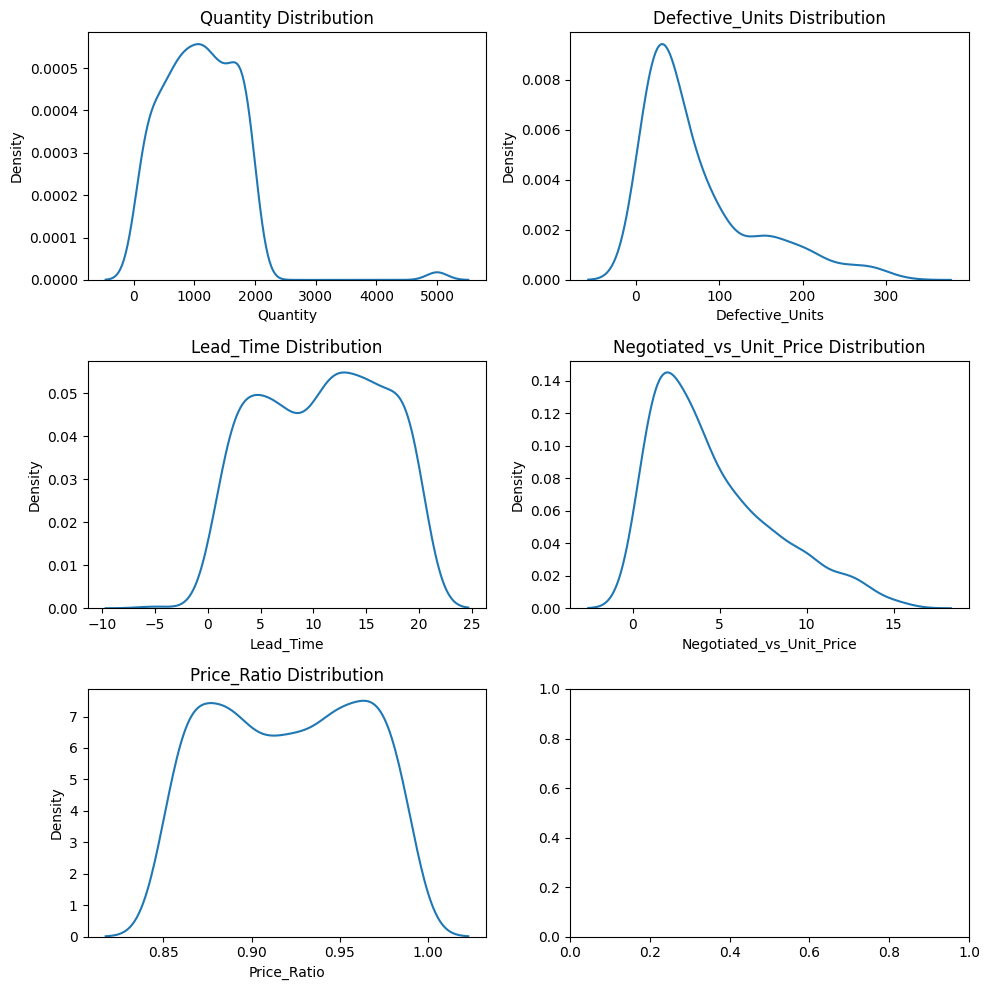

In [26]:
fig, axes = plt.subplots(3, 2, figsize=(10, 10))

axes = axes.flatten()

for i, c in enumerate(numerical_cols):
    sns.kdeplot(data=df, x=c, ax=axes[i])
    axes[i].set_xlabel(c)
    axes[i].set_ylabel('Density')
    axes[i].set_title(f'{c} Distribution')

plt.tight_layout()
plt.show()

### Correlation & Multicollinearity between Numerical Features

In [41]:
df.corr(numeric_only=True)['Defective_Units'].sort_values(ascending=False)

Defective_Units             1.000000
Quantity                    0.459988
Lead_Time                   0.034880
Price_Ratio                 0.019115
Negotiated_vs_Unit_Price   -0.013373
Name: Defective_Units, dtype: float64

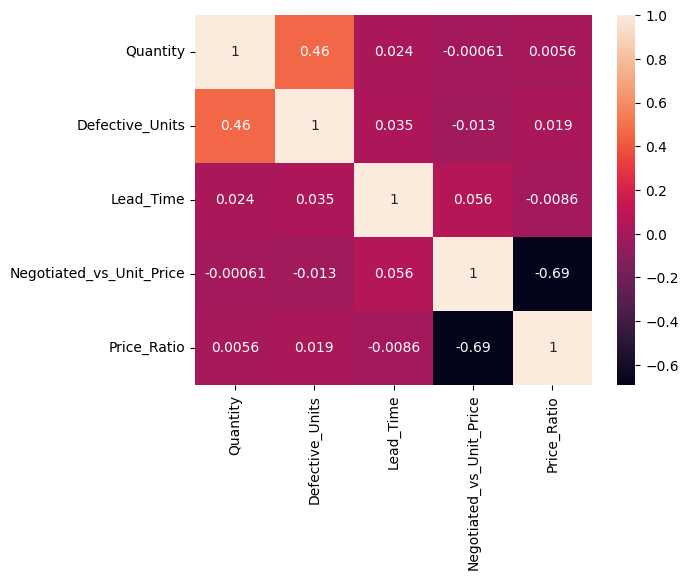

In [28]:
sns.heatmap(df.corr(), annot=True)
plt.show()

Quantity, Lead Time, and Price Ratio show a positive correlation with **Defective Units**, while **Quantity** has the strongest correlation among them.

Negotiated vs Unit Price and Price Ratio are highly correlated features, so we can use either one of them.

### Outliers in Numerical Features

In [29]:
df[numerical_cols].describe()

,Quantity,Defective_Units,Lead_Time,Negotiated_vs_Unit_Price,Price_Ratio
count,777.000000,641.000000,690.000000,777.000000,777.000000
mean,1094.660232,74.803432,10.776812,4.623102,0.920319
std,647.844551,69.187870,5.729210,3.455732,0.041387
min,51.000000,0.000000,-5.000000,0.180000,0.850075
25%,615.000000,26.000000,6.000000,1.900000,0.884716
50%,1075.000000,49.000000,11.000000,3.650000,0.920995
75%,1548.000000,100.000000,16.000000,6.640000,0.957203
max,5000.000000,321.000000,20.000000,15.560000,0.989946


<AxesSubplot: >

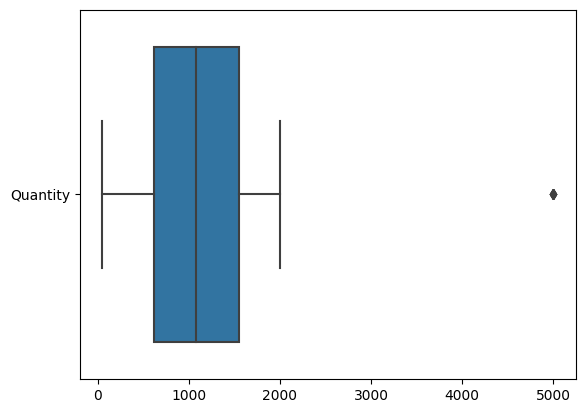

In [30]:
sns.boxplot(df[['Quantity']], orient='h')

<AxesSubplot: >

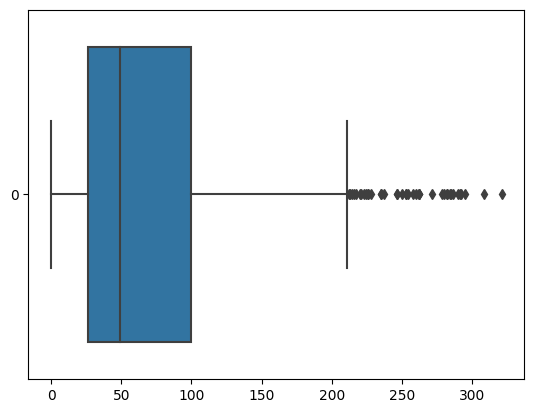

In [31]:
sns.boxplot(df['Defective_Units'], orient='h')

### Scatter Plot

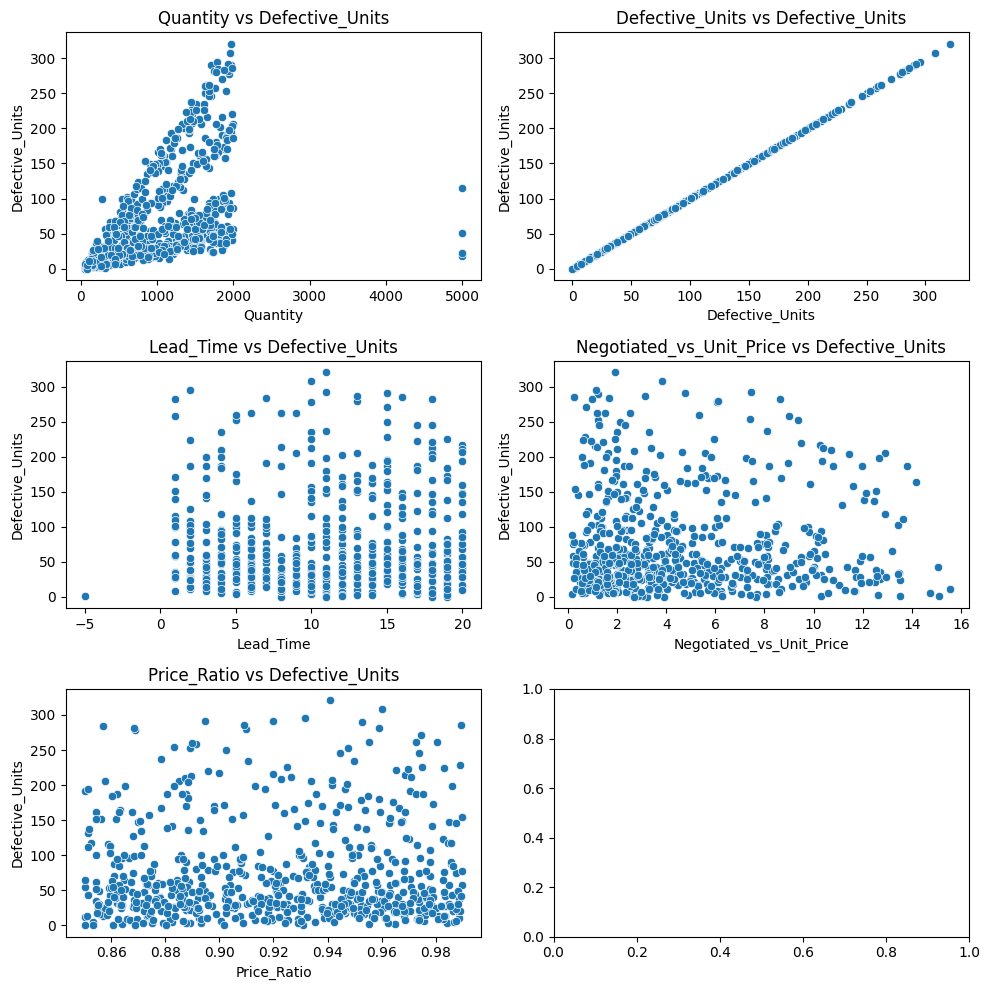

In [32]:
fig, axes = plt.subplots(3, 2, figsize=(10,10))
axes = axes.flatten()

for i, c in enumerate(numerical_cols):
    sns.scatterplot(data=df, x=c, y='Defective_Units', ax=axes[i])
    axes[i].set_xlabel(c)
    axes[i].set_ylabel('Defective_Units')
    axes[i].set_title(f'{c} vs Defective_Units')

plt.tight_layout()
plt.show()

### Categorical Values

In [33]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols

['PO_ID', 'Supplier', 'Item_Category', 'Compliance']

In [34]:
print(df['Supplier'].value_counts())
print('\nValue Distribution\n-----------------------------')
print(np.round(df['Supplier'].value_counts()/df['Supplier'].count()*100))

Delta_Logistics    171
Epsilon_Group      166
Beta_Supplies      156
Gamma_Co           143
Alpha_Inc          141
Name: Supplier, dtype: int64

Value Distribution
-----------------------------
Delta_Logistics    22.0
Epsilon_Group      21.0
Beta_Supplies      20.0
Gamma_Co           18.0
Alpha_Inc          18.0
Name: Supplier, dtype: float64


In [35]:
print(df['Item_Category'].value_counts())
print('\nValue Distribution\n-----------------------------')
print(np.round(df['Item_Category'].value_counts()/df['Item_Category'].count()*100))

Office Supplies    174
MRO                164
Electronics        152
Packaging          148
Raw Materials      139
Name: Item_Category, dtype: int64

Value Distribution
-----------------------------
Office Supplies    22.0
MRO                21.0
Electronics        20.0
Packaging          19.0
Raw Materials      18.0
Name: Item_Category, dtype: float64


In [36]:
print(df['Compliance'].value_counts())
print('\nValue Distribution\n-----------------------------')
print(np.round(df['Compliance'].value_counts()/df['Compliance'].count()*100))

Yes    640
No     137
Name: Compliance, dtype: int64

Value Distribution
-----------------------------
Yes    82.0
No     18.0
Name: Compliance, dtype: float64
